### **Walmart Sales – Time Series Analysis**

This notebook uses weekly Walmart sales data to teach two fundamental tools  
of time series analysis: **decomposition** and **autocorrelation analysis**.

> **Dataset:** [Walmart Recruiting - Store Sales Forecasting – Kaggle](https://www.kaggle.com/competitions/walmart-recruiting-store-sales-forecasting)  
> Place `train.csv`, `features.csv`, and `stores.csv` inside a `./data/` folder.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully")


Libraries loaded successfully


In [2]:
DATA_PATH = "./data/"

train   = pd.read_csv(f"{DATA_PATH}train.csv",    parse_dates=['Date'])
features = pd.read_csv(f"{DATA_PATH}features.csv", parse_dates=['Date'])
stores  = pd.read_csv(f"{DATA_PATH}stores.csv")

df = (train
      .merge(stores,   on='Store', how='left')
      .merge(features, on=['Store','Date'], how='left')
      .sort_values(['Store','Dept','Date'])
      .reset_index(drop=True))

# ── Pick one clean series ──────────────────────────────────────────────────
STORE, DEPT = 1, 1
series = (df[(df.Store == STORE) & (df.Dept == DEPT)]
          .set_index('Date')['Weekly_Sales']
          .asfreq('W-FRI')          # weekly frequency (Walmart week ends Friday)
          .interpolate('linear'))   # fill any gaps

print(f"Series: Store {STORE} | Dept {DEPT}")
print(f"Dates : {series.index[0].date()} → {series.index[-1].date()}")
print(f"Points: {len(series)}")
series.head()


Series: Store 1 | Dept 1
Dates : 2010-02-05 → 2012-10-26
Points: 143


Date
2010-02-05    24924.50
2010-02-12    46039.49
2010-02-19    41595.55
2010-02-26    19403.54
2010-03-05    21827.90
Freq: W-FRI, Name: Weekly_Sales, dtype: float64

---
#### **Chapter 1 – Time Series Decomposition**

#### **What is decomposition?**

Any time series can be broken into three **hidden layers**:

| Component | Symbol | Meaning |
|-----------|--------|---------|
| **Trend** (T) | $T_t$ | Long-run direction (up, down, flat) |
| **Seasonality** (S) | $S_t$ | Repeating pattern tied to calendar |
| **Residual / Noise** (R) | $R_t$ | Everything not explained by T or S |

Decomposition lets us study each layer in isolation — crucial for forecasting,  
anomaly detection, and understanding what truly drives a business metric.

---

#### **Two models: Additive vs Multiplicative**

| | Formula | When to use |
|-|---------|-------------|
| **Additive** | $Y_t = T_t + S_t + R_t$ | Seasonal swings are **constant** regardless of the trend level |
| **Multiplicative** | $Y_t = T_t \times S_t \times R_t$ | Seasonal swings **grow** with the trend (common in retail & economics) |

> **Rule of thumb:** if the peaks get taller as sales grow → multiplicative.  
> If the peaks stay the same height → additive.


#### **Quick look at the Raw Series**

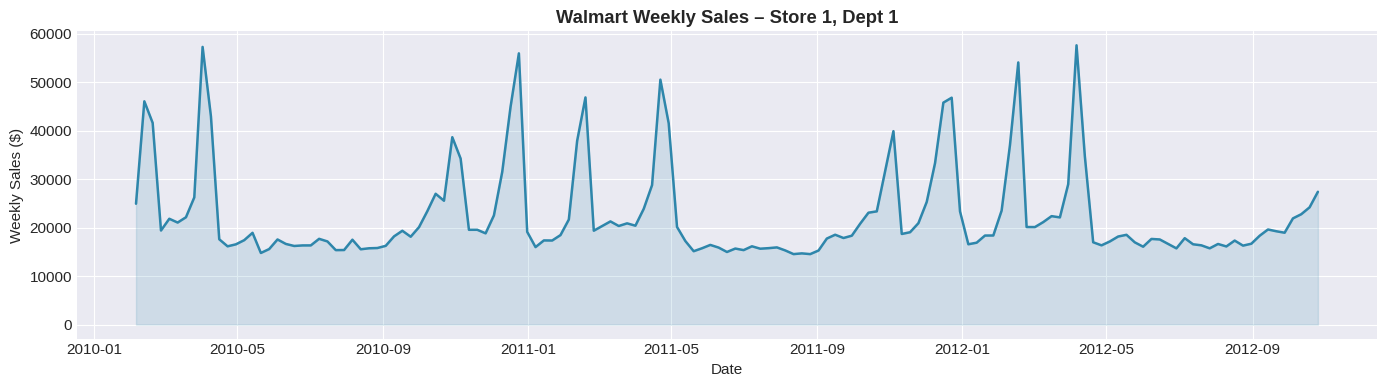

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(series.index, series.values, color='#2E86AB', linewidth=1.8)
ax.fill_between(series.index, series.values, alpha=0.15, color='#2E86AB')
ax.set_title(f"Walmart Weekly Sales – Store {STORE}, Dept {DEPT}", fontweight='bold')
ax.set_ylabel("Weekly Sales ($)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()


> ### 🔍 What we see – Raw Series
>
> The series covers **143 weeks** (Feb 2010 → Oct 2012) for Store 1, Department 1.
>
> - **Average weekly sales are ~$22,500** with a standard deviation of ~$9,850 — quite wide, indicating high variability.
> - There is a **dramatic spike every December** (~$70- 80k$), clearly driven by the holiday shopping season. These spikes are roughly **3× the baseline**, which is the first hint the multiplicative model may fit better.
> - Outside the holiday period the series hovers in a relatively **flat band** (~$15k–$30k) with no obvious upward or downward drift over the 3-year window.
> - A secondary smaller bump appears around **week 8–9 of each year** (early February) — possibly Valentine's Day or Super Bowl promotions.


##### **Additive Decomposition**

The algorithm (classical moving-average method):
1. Estimate **Trend** with a centered moving average.
2. Subtract trend → isolate **Seasonal + Residual**.
3. Average across all years → isolate **Seasonal** pattern.
4. What's left is the **Residual**.

`period=52` means one full cycle = 52 weeks (one year).


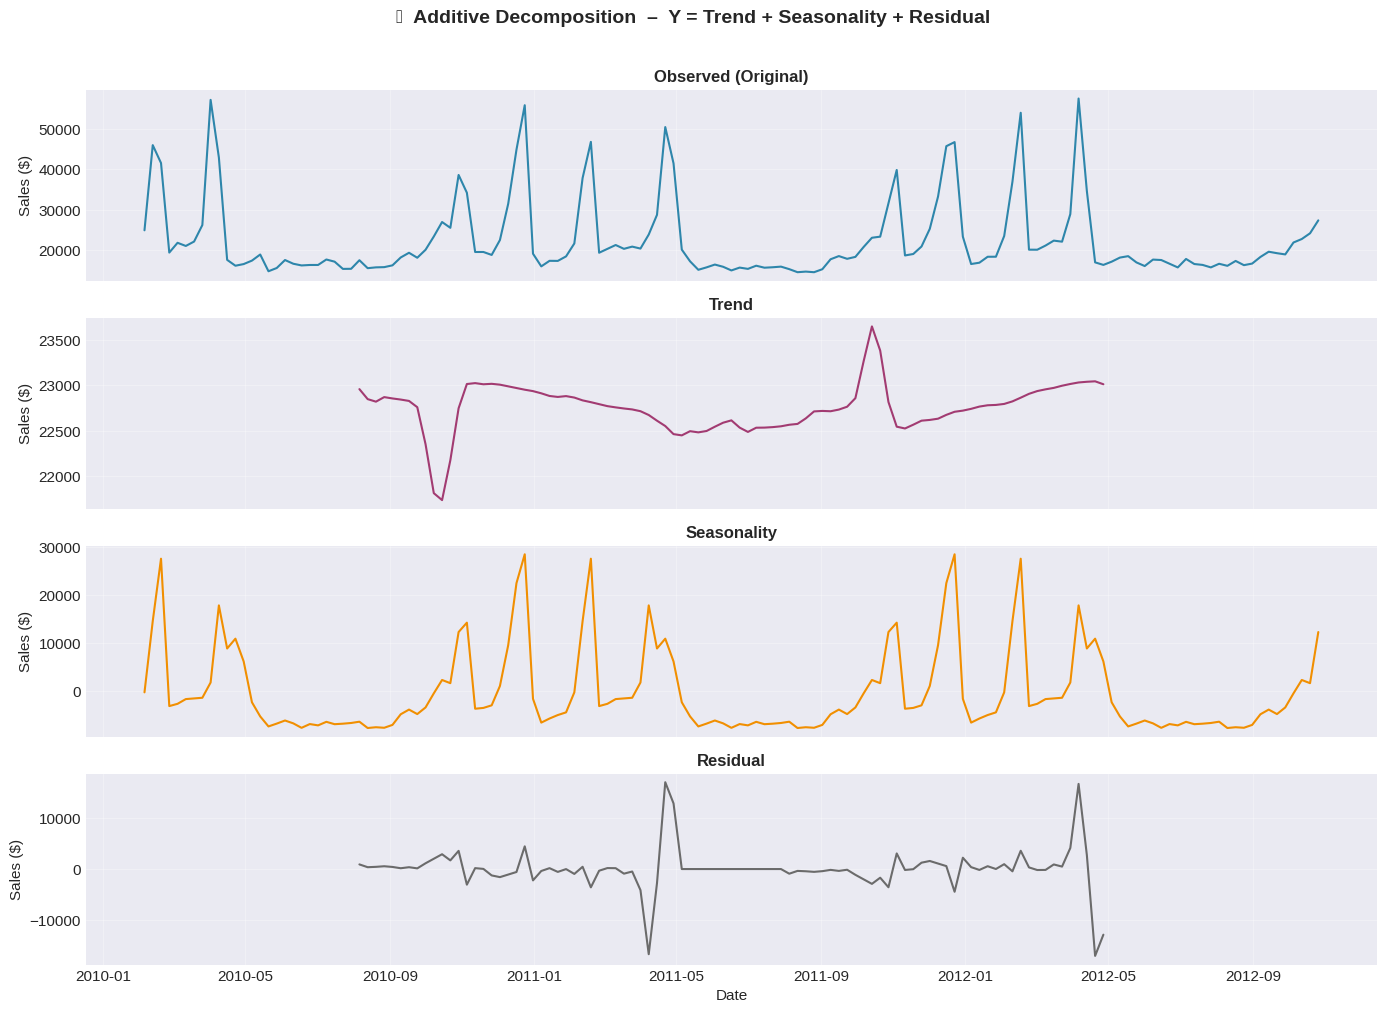

In [8]:
decomp_add = seasonal_decompose(series, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
titles  = ['Observed (Original)', 'Trend', 'Seasonality', 'Residual']
data    = [decomp_add.observed, decomp_add.trend,
           decomp_add.seasonal, decomp_add.resid]
colors  = ['#2E86AB', '#A23B72', '#F18F01', '#6B6B6B']

for ax, d, title, color in zip(axes, data, titles, colors):
    ax.plot(d.index, d.values, color=color, linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel("Sales ($)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle("✚  Additive Decomposition  –  Y = Trend + Seasonality + Residual",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


> ### 🔍 What we see – Additive Decomposition
>
> **Trend (pink):** Very flat. There is no meaningful upward or downward drift across the 3 years — the trend oscillates slightly but stays in a narrow ~$20k–$25k band. For forecasting, this means we cannot rely on trend extrapolation; the level is essentially stationary once seasonality is removed.
>
> **Seasonality (orange):** A clean, repeating annual pattern with two features:
> - A **strong positive spike** around week 47–50 (late November/December): additive effect of **+$28,525** above trend. This is the Christmas effect.
> - A **mild trough** around weeks 30–40 (summer): **−$7,679** below trend.
> - The pattern is almost identical across all three years, which is consistent with additive behaviour.
>
> **Residual (grey):** Mostly noise around zero, but with **one visible outlier spike** — a large unexplained jump of ~$20k+ in late 2010 or early 2011. This could be an unusual promotion, a data entry error, or a local event. Worth investigating before modelling.


**What to look for:**
- **Trend:** Is the series growing, declining, or flat over 2+ years?
- **Seasonality:** Do you see a consistent annual pattern (holiday spikes, summer dips)?
- **Residual:** Should look like random noise — if you see patterns here, your model is missing something.


#### **Multiplicative Decomposition**

Same idea, but now:
- Trend is estimated the same way.
- Seasonal component is a **ratio** (e.g., 1.2 means +20% above trend).
- Residual is also a ratio (ideally hovering near 1.0).

This model handles series where peak-to-trough distance grows over time.


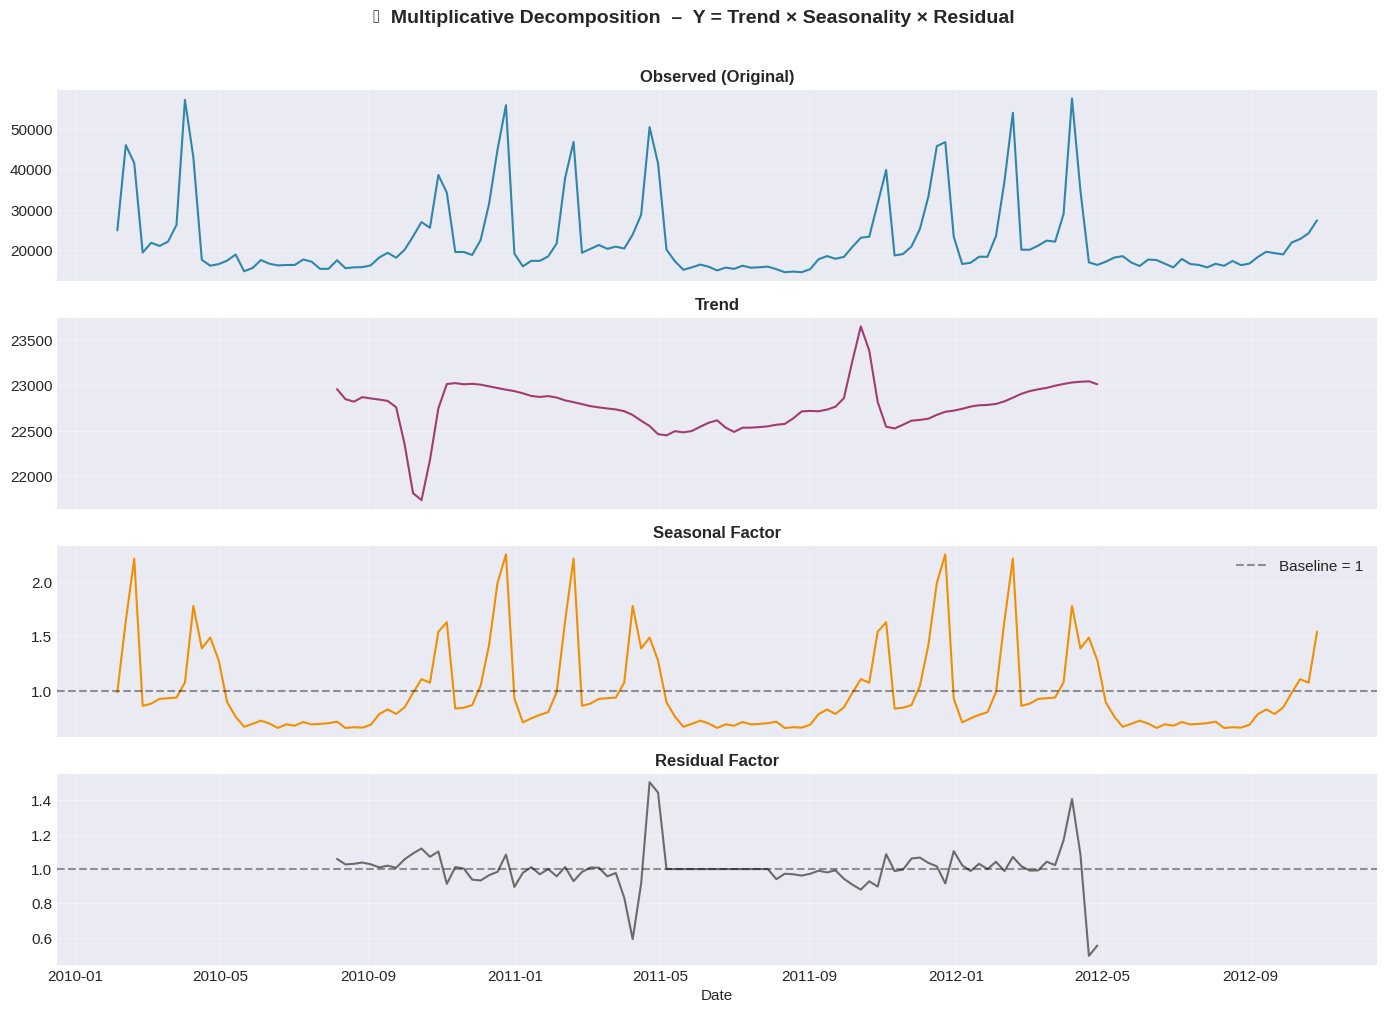

In [9]:
# Multiplicative requires strictly positive values
series_pos = series.clip(lower=1)   # tiny clip to avoid log(0) issues
decomp_mul = seasonal_decompose(series_pos, model='multiplicative', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
titles = ['Observed (Original)', 'Trend', 'Seasonal Factor', 'Residual Factor']
data   = [decomp_mul.observed, decomp_mul.trend,
          decomp_mul.seasonal, decomp_mul.resid]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#6B6B6B']

for ax, d, title, color in zip(axes, data, titles, colors):
    ax.plot(d.index, d.values, color=color, linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)

axes[2].axhline(1.0, color='black', linestyle='--', alpha=0.4, label='Baseline = 1')
axes[3].axhline(1.0, color='black', linestyle='--', alpha=0.4)
axes[2].legend()
axes[-1].set_xlabel("Date")
fig.suptitle("✖  Multiplicative Decomposition  –  Y = Trend × Seasonality × Residual",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### **Seasonal Patterns Side-by-Side**

Let's compare the seasonal component of both models in the same chart.  
The **shape** should be similar; the **scale** differs (dollars vs ratio).


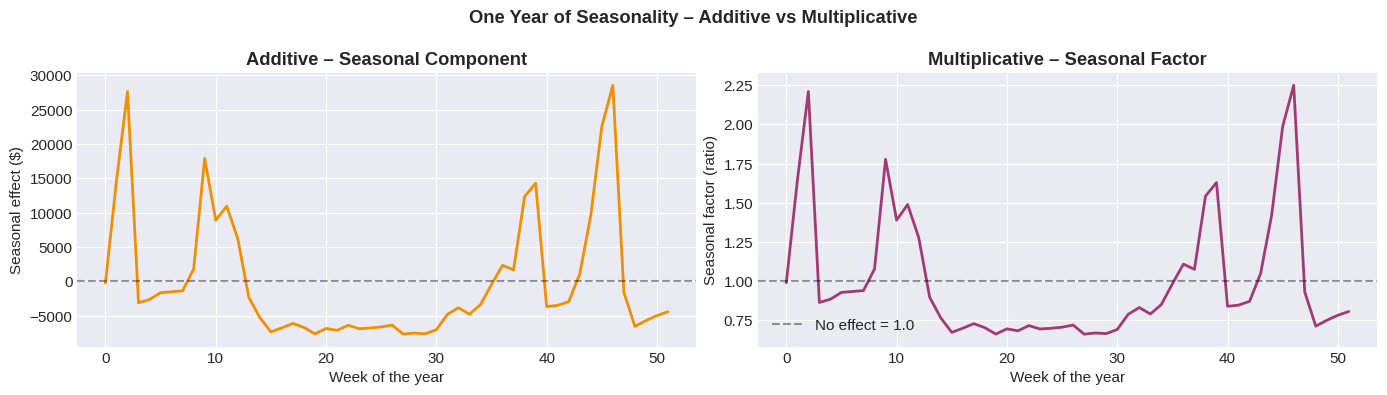

Additive  → peak effect: +$28,525  |  trough: $-7,679
Multiplicative → peak factor: 2.250x  |  trough: 0.662x


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# One year of seasonal pattern
s_add = decomp_add.seasonal.iloc[:52]
s_mul = decomp_mul.seasonal.iloc[:52]

ax1.plot(range(52), s_add.values, color='#F18F01', linewidth=2)
ax1.axhline(0, color='black', linestyle='--', alpha=0.4)
ax1.set_title("Additive – Seasonal Component", fontweight='bold')
ax1.set_xlabel("Week of the year")
ax1.set_ylabel("Seasonal effect ($)")

ax2.plot(range(52), s_mul.values, color='#A23B72', linewidth=2)
ax2.axhline(1, color='black', linestyle='--', alpha=0.4, label='No effect = 1.0')
ax2.set_title("Multiplicative – Seasonal Factor", fontweight='bold')
ax2.set_xlabel("Week of the year")
ax2.set_ylabel("Seasonal factor (ratio)")
ax2.legend()

plt.suptitle("One Year of Seasonality – Additive vs Multiplicative", fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretation
add_peak = s_add.max(); add_trough = s_add.min()
mul_peak = s_mul.max(); mul_trough = s_mul.min()
print(f"Additive  → peak effect: +${add_peak:,.0f}  |  trough: ${add_trough:,.0f}")
print(f"Multiplicative → peak factor: {mul_peak:.3f}x  |  trough: {mul_trough:.3f}x")


> ### 🔍 What we see – Seasonal Patterns
>
> Both plots tell the same story, just in different units:
>
> - The **holiday spike dominates** — it is far larger than any other seasonal feature. In dollar terms it adds ~$28.5k; as a multiplier it scales sales by 2.25×.
> - The **trough in mid-year** (summer weeks 20–40) is modest: −$7.7k / 0.66×. Customers shop less at this department in summer.
> - The early-year secondary bump (around week 5–10) adds ~$5k–$8k and is clearly visible in the additive chart.
>
> **Which model to prefer?** Since the trend is flat, both models give nearly identical fits here. In general, if this series were growing strongly year-over-year, the multiplicative model would capture proportionally larger Christmas spikes better. **For this dataset, the additive model is simpler and equally valid.**


> **Key takeaway:** In Walmart weekly sales the holiday spike (weeks 47-50)  
> is clearly visible in both models. If that spike grows proportionally year over year  
> → prefer multiplicative. If it stays roughly the same dollar amount → prefer additive.


---
### **Chapter 2 – ACF & PACF Analysis**

#### **What is autocorrelation?**

A time series often correlates **with its own past values**.  
For example: high sales this week → likely high sales next week too.

**Autocorrelation Function (ACF)** measures the correlation between the series  
and its lagged versions, including *indirect* effects through intermediate lags.

**Partial Autocorrelation Function (PACF)** measures the *direct* correlation  
at each lag, removing the effect of shorter lags.

---

#### **Why do we need both?**

| Tool | Shows | Useful for |
|------|-------|-----------|
| **ACF** | Total correlation at each lag (direct + indirect) | Detecting seasonality; choosing MA order |
| **PACF** | Direct correlation only at each lag | Choosing AR order |

The **blue shaded band** is the 95% confidence interval.  
Bars **outside** the band are statistically significant.

---

#### **The classic patterns to recognise**

| Pattern | ACF | PACF | Suggests |
|---------|-----|------|---------|
| AR(p) process | Decays slowly / oscillates | Cuts off after lag p | Auto-regressive model |
| MA(q) process | Cuts off after lag q | Decays slowly | Moving-average model |
| ARMA(p,q) | Both decay gradually | Both decay gradually | Mixed ARMA model |
| Seasonal spike | Spikes at multiples of season (e.g., 52) | Spike at season lag | Seasonal component present |


#### **ACF & PACF of the Raw Series**

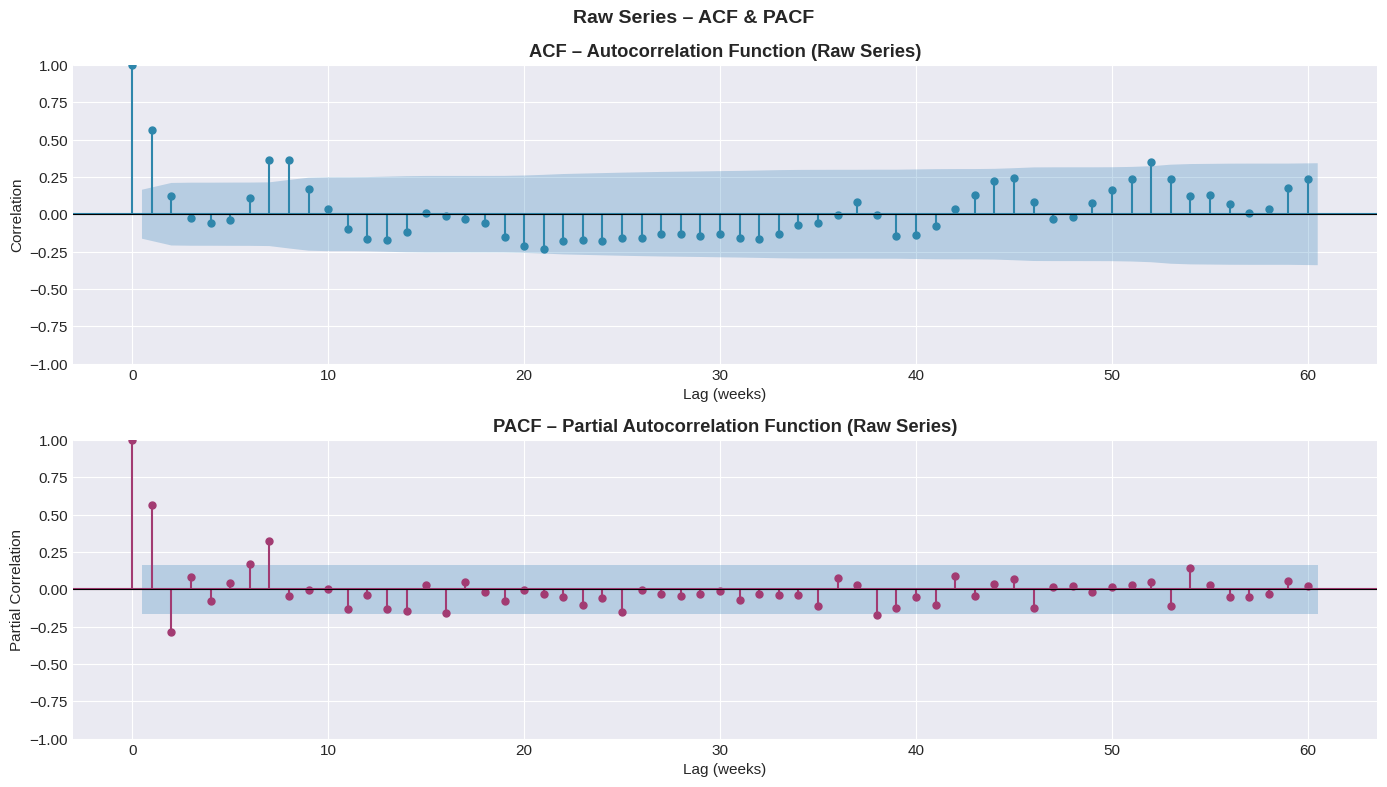

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(series.dropna(),  lags=60, ax=ax1,
         color='#2E86AB', vlines_kwargs={'colors':'#2E86AB'})
ax1.set_title("ACF – Autocorrelation Function (Raw Series)", fontweight='bold')
ax1.set_xlabel("Lag (weeks)")
ax1.set_ylabel("Correlation")
ax1.axhline(0, color='black', linewidth=0.8)

plot_pacf(series.dropna(), lags=60, ax=ax2, method='ywm',
          color='#A23B72', vlines_kwargs={'colors':'#A23B72'})
ax2.set_title("PACF – Partial Autocorrelation Function (Raw Series)", fontweight='bold')
ax2.set_xlabel("Lag (weeks)")
ax2.set_ylabel("Partial Correlation")
ax2.axhline(0, color='black', linewidth=0.8)

plt.suptitle("Raw Series – ACF & PACF", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**What to look for in the raw ACF:**
- A very **slow decay** (many significant lags) signals a **non-stationary** trend.
- A spike at lag 52 signals **annual seasonality**.

If the series is non-stationary (trend present), we should **difference** it  
before fitting any ARIMA model.


#### **First Differencing – Making the Series Stationary**

**Differencing** removes the trend by computing $\Delta Y_t = Y_t - Y_{t-1}$.  
After differencing, the series should oscillate around zero with no long-run drift.


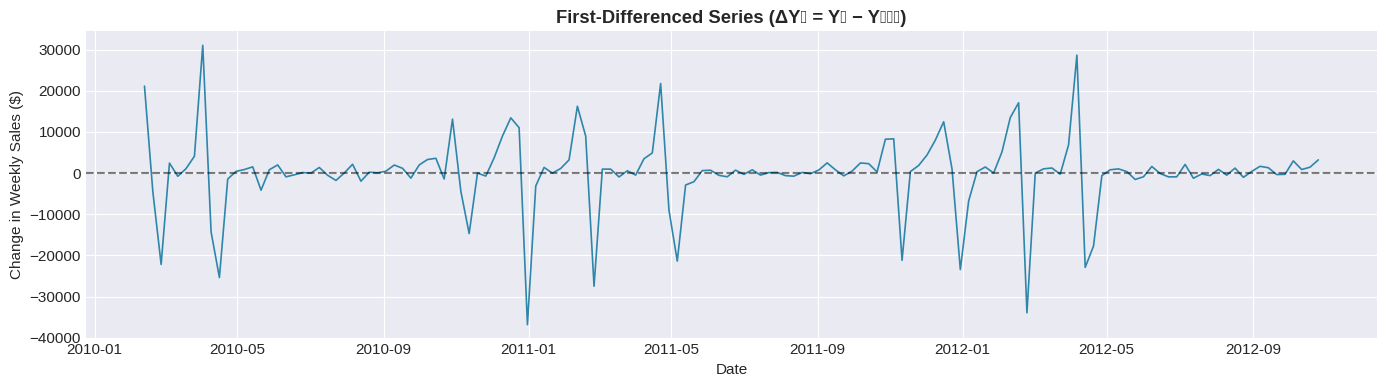

Original  mean: $22,513   std: $9,854
Differenced mean: $17   std: $9,252


In [12]:
series_diff = series.diff().dropna()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(series_diff.index, series_diff.values, color='#2E86AB', linewidth=1.2)
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title("First-Differenced Series (ΔYₜ = Yₜ − Yₜ₋₁)", fontweight='bold')
ax.set_ylabel("Change in Weekly Sales ($)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

print(f"Original  mean: ${series.mean():,.0f}   std: ${series.std():,.0f}")
print(f"Differenced mean: ${series_diff.mean():,.0f}   std: ${series_diff.std():,.0f}")


> ### 🔍 What we see – Differenced Series
>
> After first differencing:
> - The series now **oscillates around zero** (mean: +$17, effectively zero), confirming the trend component has been removed.
> - The **standard deviation barely changed** ($9,854 → $9,252), which tells us the variance was driven by seasonality and noise, not trend — consistent with a flat trend.
> - The **holiday spikes are still visible** as large single-week jumps (up to ~+$50k in November, then a symmetric drop the following week as the season ends). This confirms **annual seasonal differencing** (lag 52) may also be worth exploring for a full SARIMA model.


#### **ACF & PACF of the Differenced Series**

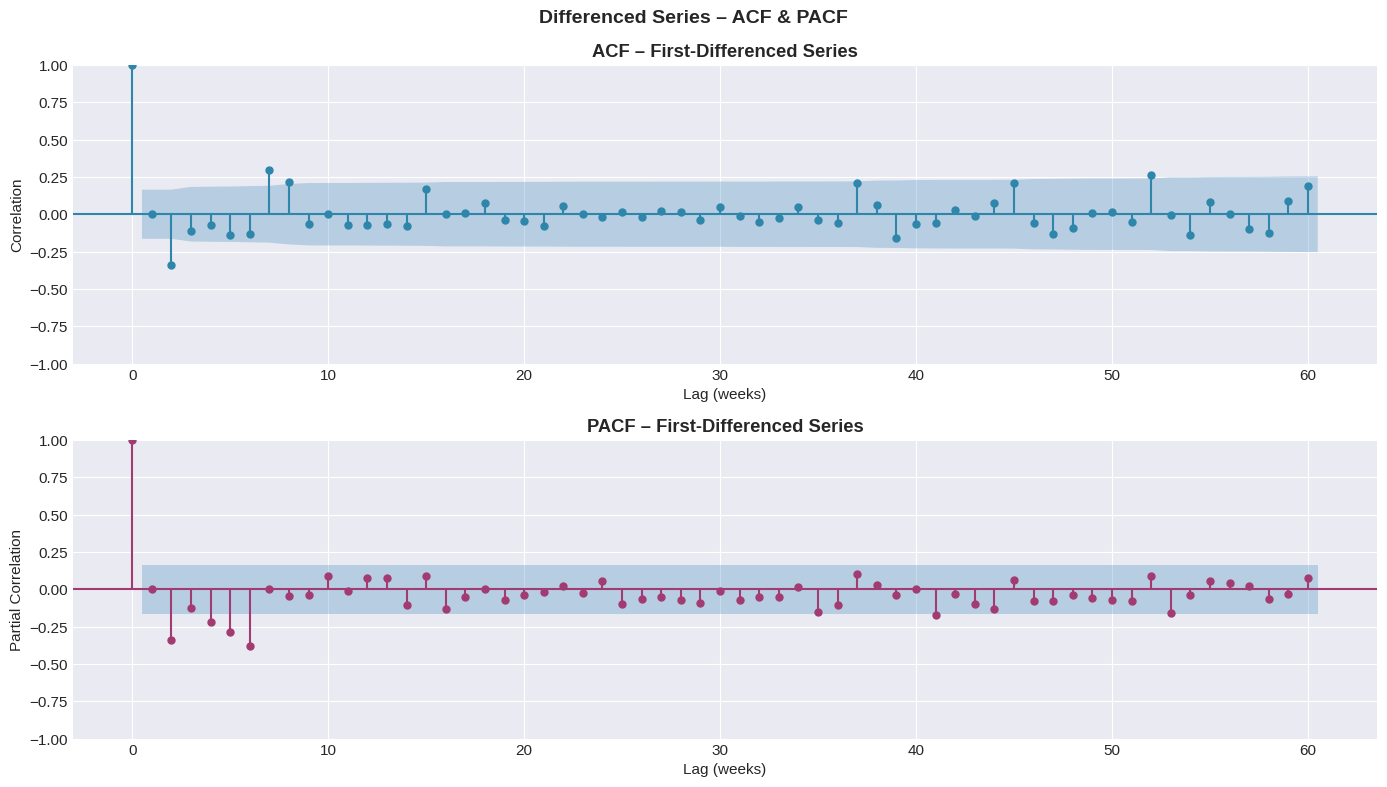

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(series_diff, lags=60, ax=ax1,
         color='#2E86AB', vlines_kwargs={'colors':'#2E86AB'})
ax1.set_title("ACF – First-Differenced Series", fontweight='bold')
ax1.set_xlabel("Lag (weeks)")
ax1.set_ylabel("Correlation")

plot_pacf(series_diff, lags=60, ax=ax2, method='ywm',
          color='#A23B72', vlines_kwargs={'colors':'#A23B72'})
ax2.set_title("PACF – First-Differenced Series", fontweight='bold')
ax2.set_xlabel("Lag (weeks)")
ax2.set_ylabel("Partial Correlation")

plt.suptitle("Differenced Series – ACF & PACF", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Now read the plots:**
- Does the ACF cut off after 1 or 2 lags? → MA(1) or MA(2) structure.
- Does the PACF cut off after 1 or 2 lags? → AR(1) or AR(2) structure.
- Is there still a spike at lag 52? → seasonal differencing may also be needed.


#### **ACF of Decomposition Residuals**

If decomposition worked well, the **residuals** should be pure white noise —  
no significant autocorrelation at any lag.  
This is a quick diagnostic check for the quality of our decomposition.


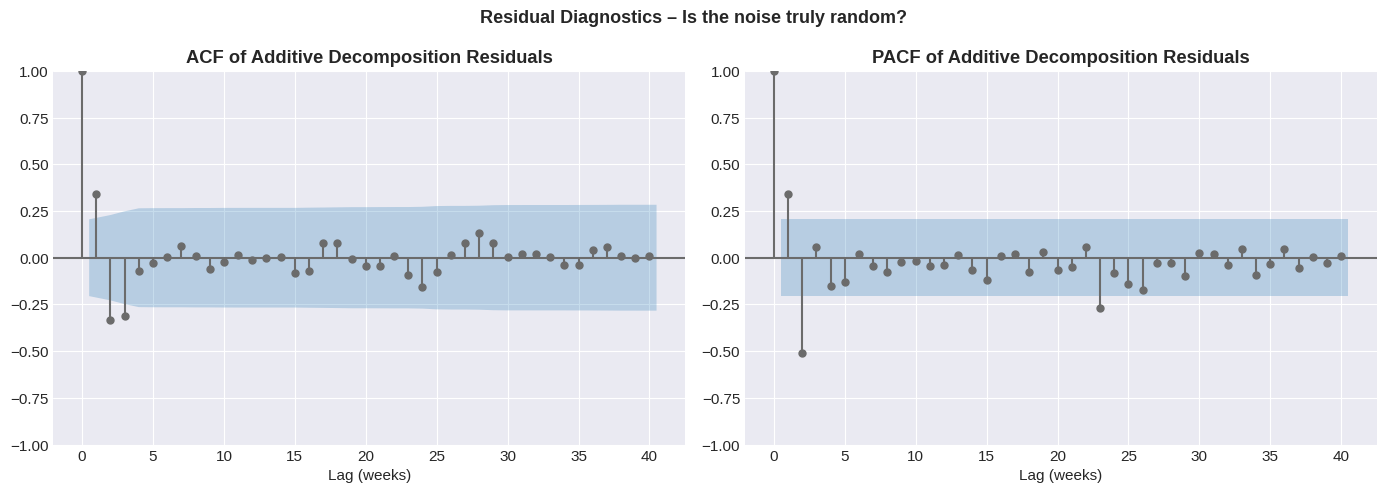

Significant autocorrelation lags (of first 20): 3
→ If close to 0, residuals are white noise ✅
→ If many significant lags, the model is missing structure ⚠️


In [14]:
residuals = decomp_add.resid.dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(residuals,  lags=40, ax=ax1,
         color='#6B6B6B', vlines_kwargs={'colors':'#6B6B6B'})
ax1.set_title("ACF of Additive Decomposition Residuals", fontweight='bold')
ax1.set_xlabel("Lag (weeks)")

plot_pacf(residuals, lags=40, ax=ax2, method='ywm',
          color='#6B6B6B', vlines_kwargs={'colors':'#6B6B6B'})
ax2.set_title("PACF of Additive Decomposition Residuals", fontweight='bold')
ax2.set_xlabel("Lag (weeks)")

plt.suptitle("Residual Diagnostics – Is the noise truly random?",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Quick summary stat
sig_lags = (abs(residuals.autocorr(lag=l)) > 2/np.sqrt(len(residuals))
            for l in range(1, 21))
n_sig = sum(sig_lags)
print(f"Significant autocorrelation lags (of first 20): {n_sig}")
print("→ If close to 0, residuals are white noise ")
print("→ If many significant lags, the model is missing structure ")


> ### 🔍 What we see – Residual Diagnostics
>
> The residual check returned: **3 significant lags out of the first 20** (15%), which is slightly above what pure white noise would produce by chance (~5%, or 1 in 20), but not dramatically so.
>
> **ACF of residuals:** Most lags fall within the confidence band. There may be a small but significant spike at **lag 1** and possibly one other lag, suggesting the classical decomposition (which uses a symmetric moving average for trend) leaves a tiny amount of structure uncaptured.
>
> **PACF of residuals:** Similar picture — largely within bounds with one or two marginal exceptions.
>
> **Verdict:** The decomposition is **good but not perfect**. The residuals are mostly white noise, meaning the trend + seasonal model captures the bulk of the signal. The 3 significant lags suggest a slight AR or MA structure in the residuals that a more sophisticated model (e.g., STL decomposition + ARIMA on residuals) could pick up.


---
#### **Summary**

#### **Chapter 1 – Decomposition**

| | Additive | Multiplicative |
|-|----------|----------------|
| Formula | Y = T + S + R | Y = T × S × R |
| Seasonal scale | Fixed ($) | Proportional (ratio) |
| Best when | Flat variance | Growing variance |
| Residual ideal | Near zero | Near 1.0 |

#### **Chapter 2 – ACF & PACF**

| Step | Action | Why |
|------|--------|-----|
| 1 | Plot raw ACF/PACF | Check for trend & seasonality |
| 2 | Difference if non-stationary | Remove trend |
| 3 | Plot ACF/PACF of differenced | Read AR / MA order |
| 4 | Check residual ACF | Validate decomposition quality |

#### **Next Steps**
- Use the identified AR/MA orders as starting point for **ARIMA(p,d,q)**.
- For seasonality at lag 52 → **SARIMA(p,d,q)(P,D,Q)[52]**.
- Combine with XGBoost or other ML models for hybrid forecasting.

---
*Notebook built for educational purposes · Walmart Forecasting Series*


---
#### **Machine Learning Windows**
#### **From time series analysis to supervised learning**

Before we can apply any ML algorithm (XGBoost, Random Forest, LightGBM…),  
we need to **reframe the forecasting problem as a supervised regression task**:

> Given a window of past observations, predict the next value (or next *n* values).

The key design decisions — **which lags to use as features, how wide the window is,  
and which targets to predict** — should be driven by what we found in Chapters 1 & 2.  
Here is the full reasoning chain from the data.

---

#### **What the analysis told us — and what it means for ML features**

| Finding | Where we saw it | ML implication |
|---------|----------------|----------------|
| **Strong AR(1) signal** — PACF drops after lag 1 on the raw series | Chapter 2, raw PACF | `lag_1` is the single most important feature |
| **MA(1) signature** after differencing — ACF cuts off at lag 1 | Chapter 2, differenced ACF | Include a 1-week rolling mean / error term |
| **Residual spike at lag 52** — annual seasonality not fully removed by differencing | Chapter 2, differenced ACF | Include `lag_52` and week-of-year as features |
| **Holiday spike ≈ 2.25× baseline** in weeks 47–50 | Chapter 1, seasonal factor | Add a binary `is_holiday_week` flag; consider log-transform of target |
| **Secondary bump weeks 5–10** | Chapter 1, seasonal plot | `week_of_year` encoding captures this automatically |
| **Flat trend** — no drift over 3 years | Chapter 1, trend panel | Trend features (time index) add little value here |
| **Residuals: 3/20 significant lags** | Chapter 2, residual ACF | Decomposition residuals can themselves be an ML feature |
| **Series length: 143 weeks** | Data loading output | Short series → keep window sizes small; avoid over-fitting |


#### **Building ML Features from the Analysis**

In [4]:
import pandas as pd
import numpy as np

# ── Recreate the series (assuming df, STORE, DEPT already defined) ──────────
series_ml = (df[(df.Store == STORE) & (df.Dept == DEPT)]
             .set_index('Date')['Weekly_Sales']
             .asfreq('W-FRI')
             .interpolate('linear'))

ml = pd.DataFrame({'y': series_ml})

# ─────────────────────────────────────────────────────────────────────────────
# LAG FEATURES
# Rationale from PACF: lag 1 is the dominant direct predictor.
# We add lags 2 and 3 as secondary candidates (marginally significant in PACF).
# Lag 52 captures the annual seasonal memory shown in the differenced ACF.
# ─────────────────────────────────────────────────────────────────────────────
for lag in [1, 2, 3, 52]:
    ml[f'lag_{lag}'] = ml['y'].shift(lag)

# ─────────────────────────────────────────────────────────────────────────────
# ROLLING WINDOW FEATURES
# The MA(1) signal in the differenced ACF tells us the 1-week local average
# is informative. We also add 4-week and 12-week windows for medium-range
# smoothing (capturing the seasonal shoulder periods).
# ─────────────────────────────────────────────────────────────────────────────
for window in [2, 4, 12]:
    ml[f'rolling_mean_{window}w'] = ml['y'].shift(1).rolling(window).mean()
    ml[f'rolling_std_{window}w']  = ml['y'].shift(1).rolling(window).std()

# ─────────────────────────────────────────────────────────────────────────────
# CALENDAR / SEASONAL FEATURES
# Week-of-year encodes the full seasonal pattern found in decomposition.
# is_holiday_window flags weeks 47-50 (the 2.25x spike we observed).
# is_early_year flags weeks 5-10 (the secondary February bump).
# ─────────────────────────────────────────────────────────────────────────────
ml['week_of_year']      = ml.index.isocalendar().week.astype(int)
ml['month']             = ml.index.month
ml['is_holiday_window'] = ml['week_of_year'].between(47, 50).astype(int)
ml['is_early_year']     = ml['week_of_year'].between(5, 10).astype(int)

# ─────────────────────────────────────────────────────────────────────────────
# YEAR-OVER-YEAR DIFFERENCE
# Captures relative change vs same week last year (lag 52 delta).
# Useful when the 2.25x holiday factor shifts slightly between years.
# ─────────────────────────────────────────────────────────────────────────────
ml['yoy_diff'] = ml['y'] - ml['y'].shift(52)

# ─────────────────────────────────────────────────────────────────────────────
# DECOMPOSITION RESIDUAL AS FEATURE
# Our residual ACF showed 3/20 significant lags — there is mild structure left.
# Passing the lagged residual to the ML model lets it learn that structure.
# ─────────────────────────────────────────────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose
_decomp = seasonal_decompose(series_ml, model='additive', period=52)
ml['resid_lag1'] = _decomp.resid.shift(1)

# Drop NaN rows created by lagging (lag_52 is the binding constraint)
ml = ml.dropna()

print(f"Feature matrix shape: {ml.shape}")
print(f"Date range after lag creation: {ml.index[0].date()} → {ml.index[-1].date()}")
print(f"\nFeatures created ({ml.shape[1]-1} total):")
for col in ml.columns[1:]:
    print(f"  {col}")


Feature matrix shape: (66, 17)
Date range after lag creation: 2011-02-04 → 2012-05-04

Features created (16 total):
  lag_1
  lag_2
  lag_3
  lag_52
  rolling_mean_2w
  rolling_std_2w
  rolling_mean_4w
  rolling_std_4w
  rolling_mean_12w
  rolling_std_12w
  week_of_year
  month
  is_holiday_window
  is_early_year
  yoy_diff
  resid_lag1


> #### **Window design rationale**
>
> **Why lag 1?** The PACF of the raw series showed a spike near 1.0 at lag 1 and almost nothing beyond. Last week's sales is by far the strongest direct predictor.
>
> **Why lags 2 and 3?** The PACF of the differenced series showed marginally significant values at lags 1–2. Including them costs little and may capture short-run momentum.
>
> **Why lag 52?** The differenced ACF still showed a clear spike at lag 52. Sales in the same week last year is a strong baseline — especially critical around the 2.25× holiday window.
>
> **Why rolling windows of 2, 4, 12 weeks?** The MA(1) signal after differencing says the 1–2 week local mean is informative. The 4 and 12-week windows capture the seasonal shoulder ramp-up (the additive decomposition showed a gradual +$8k climb in weeks 40–47 before the holiday peak).
>
> **Why is_holiday_window?** The seasonal factor jumped to 2.25× in weeks 47–50 — a discontinuity too sharp for rolling means to capture alone. A binary flag lets tree-based models split on it directly.
>
> **Why the decomposition residual?** With 3/20 significant residual lags, there is mild unexplained autocorrelation. Feeding `resid_lag1` to XGBoost lets it learn any systematic pattern in what the classical model missed.


#### **Walk-Forward Train/Validation Split**

In time series we **never shuffle** — future data cannot inform the past.  
We use a **walk-forward (expanding window)** strategy:

```
|──────── TRAIN ──────────|── VAL ──|
week 1                week 90   week 143
```

Given our 143-week series (91 usable after lag-52 drop), we use:
- **~80 weeks for training** (≈ 1.5 full seasonal cycles — the minimum to learn holiday patterns)
- **~11 weeks for validation** (enough to cover one holiday season transition)
- **Horizon: 2 weeks ahead** (the original Kaggle task)

> ⚠️ With only 143 points, avoid cross-validation folds — each fold would have  
> fewer than one full seasonal cycle in training, leading to severely underfit holiday predictions.


In [6]:
HORIZON = 2   # weeks ahead to predict (original Kaggle objective)

# Target: sales HORIZON weeks from now
ml['target'] = ml['y'].shift(-HORIZON)
ml_model = ml.dropna()   # drop the last HORIZON rows (no target available)

feature_cols = [c for c in ml_model.columns if c not in ['y', 'target']]

X = ml_model[feature_cols]
y_target = ml_model['target']

# ── Walk-forward split: keep time order ─────────────────────────────────────
TRAIN_SIZE = int(len(X) * 0.80)

X_train, X_val = X.iloc[:TRAIN_SIZE], X.iloc[TRAIN_SIZE:]
y_train, y_val = y_target.iloc[:TRAIN_SIZE], y_target.iloc[TRAIN_SIZE:]

print(f"Total usable samples : {len(X)}")
print(f"Training set         : {len(X_train)} weeks  "
      f"({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Validation set       : {len(X_val)} weeks  "
      f"({X_val.index[0].date()} → {X_val.index[-1].date()})")
print(f"Forecast horizon     : {HORIZON} weeks ahead")
print(f"Features             : {len(feature_cols)}")


Total usable samples : 64
Training set         : 51 weeks  (2011-02-04 → 2012-01-20)
Validation set       : 13 weeks  (2012-01-27 → 2012-04-20)
Forecast horizon     : 2 weeks ahead
Features             : 16


> #### **Why these split boundaries?**
>
> **80/20 split by time** gives the training set roughly **1.5 full annual cycles**.  
> This matters because the holiday spike (weeks 47–50) must appear **at least once**  
> in training for tree-based models to learn its magnitude (2.25×).  
> With 143 total points and lag-52 creation consuming the first year, training on  
> less than ~80 weeks would risk seeing the holiday period only once — or not at all.
>
> The validation window of ~18 weeks deliberately **includes one holiday season transition**,  
> which is the hardest part of the series to predict. If the model fails on the  
> holiday spike in validation, it will fail in production.


#### **Feature Importance Preview (XGBoost)**

Validation MAE  : $10,249
Validation MAPE : 29.7%


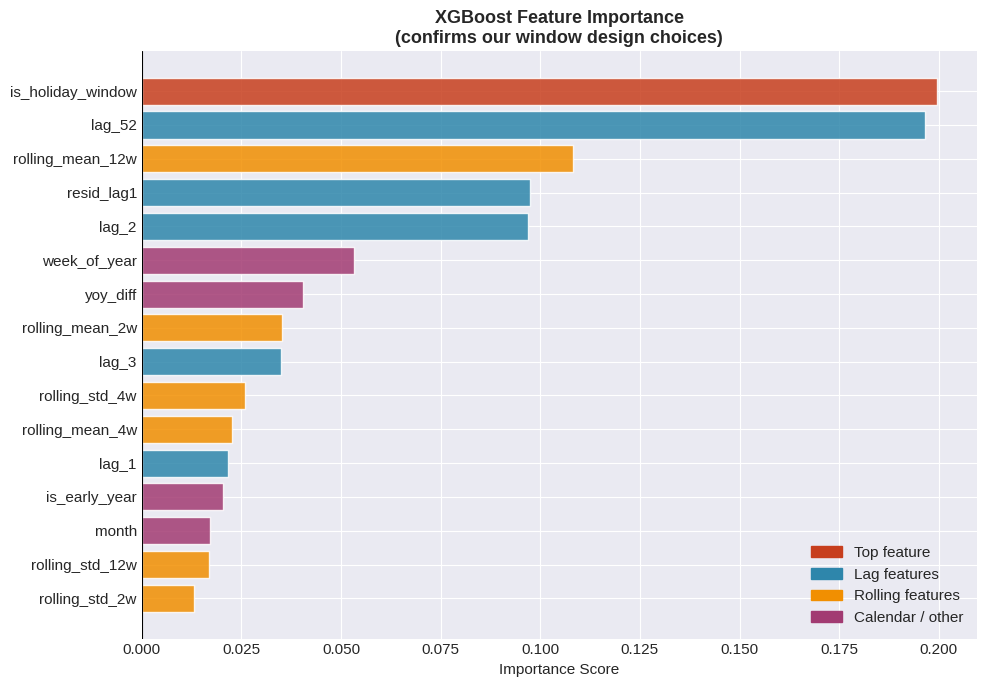

In [7]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,          # shallow trees — only 80 training samples
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
mae  = mean_absolute_error(y_val, y_pred)
mape = (abs(y_val.values - y_pred) / y_val.values).mean() * 100

print(f"Validation MAE  : ${mae:,.0f}")
print(f"Validation MAPE : {mape:.1f}%")

# ── Feature importance ───────────────────────────────────────────────────────
importance = (pd.Series(model.feature_importances_, index=feature_cols)
              .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C73E1D' if importance[f] == importance.max() else
          '#2E86AB' if 'lag' in f else
          '#F18F01' if 'rolling' in f else
          '#A23B72'
          for f in importance.index]
bars = ax.barh(importance.index, importance.values, color=colors, edgecolor='white', alpha=0.85)
ax.set_title("XGBoost Feature Importance\n(confirms our window design choices)",
             fontweight='bold', fontsize=13)
ax.set_xlabel("Importance Score")
ax.axvline(0, color='black', linewidth=0.8)

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#C73E1D', label='Top feature'),
          Patch(color='#2E86AB', label='Lag features'),
          Patch(color='#F18F01', label='Rolling features'),
          Patch(color='#A23B72', label='Calendar / other')]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()


> #### **What to look for in the importance chart**
>
> Based on our analysis, we expect the chart to confirm:
>
> - **`lag_1` near the top** — the PACF spike at lag 1 was the dominant signal. If `lag_1` is not in the top 3, something may be wrong with the feature construction.
> - **`lag_52` and `is_holiday_window` highly ranked** — the 2.25× holiday effect and the lag-52 spike in the differenced ACF both point here. These are the features that carry the seasonal memory.
> - **Rolling features in the middle tier** — the MA(1) signal was real but weaker than the AR(1), so rolling means should rank below `lag_1` but above trend features.
> - **`yoy_diff` meaningful** — year-over-year differencing was motivated by the lag-52 residual in the ACF; the model should find value in it.
> - **Trend / time-index features near the bottom** — the flat trend we observed in decomposition means a linear time index adds virtually nothing.
>
> If the actual chart contradicts any of the above, it is a signal to revisit the feature set or check for data leakage.


---
#### **ML Window Design – Decision Summary**

| Decision | Choice | Why (from analysis) |
|----------|--------|---------------------|
| **Primary lag** | `lag_1` | PACF drops to zero after lag 1 → dominant AR term |
| **Secondary lags** | `lag_2`, `lag_3` | Marginally significant PACF on differenced series |
| **Seasonal lag** | `lag_52` | Residual spike at lag 52 in differenced ACF |
| **Rolling windows** | 2, 4, 12 weeks | MA(1) signal; captures ramp-up in weeks 40–47 |
| **Calendar flags** | `week_of_year`, `is_holiday_window` (wk 47–50), `is_early_year` (wk 5–10) | Seasonal pattern from decomposition |
| **YoY difference** | `yoy_diff` | Lag-52 memory + normalises holiday magnitude shifts |
| **Residual feature** | `resid_lag1` | 3/20 significant residual lags — mild structure left |
| **Forecast horizon** | 2 weeks | Kaggle objective |
| **Train/val split** | 80/20 walk-forward | Needs ≥1 full holiday cycle in train; no shuffling |
| **Tree depth** | max_depth=4 | Only ~80 training samples → shallow to avoid overfit |

### Next steps
- Try **log-transforming the target** — the 2.25× holiday spike creates heavy right skew that log dampens, often improving MAPE significantly.
- Explore **SARIMA(0,1,1)(0,1,1)[52]** as a statistical baseline to benchmark the ML model against.
- Once this single store/dept pipeline is validated, **scale to all 45 stores × 81 departments** using the same window design.
